In [4]:
import numpy as np

# Propriedades físicas da Água a 20°C
MU_WATER = 1.002e-3  # Pa.s
RHO_WATER = 998.0    # kg/m^3
PATM = 101325.0      # Pa

# Geometria dos canais microfluídicos
DIAMETER = 100e-6    # 100 micrometros
AREA = np.pi * (DIAMETER**2) / 4
LENGTH_INLET = 5e-3  # 5 mm
LENGTH_OUTLET = 10e-3 # 10 mm

# Vazões externas (Conservação de massa: soma deve ser 0)
# 10 uL/min convertido para m^3/s
Q_IN = 10 * (1e-9 / 60) 

nodes = ["inlet_A", "inlet_B", "junction", "outlet"]

edges = {
    "inlet_A": {"junction": {"area": AREA, "length": LENGTH_INLET}},
    "inlet_B": {"junction": {"area": AREA, "length": LENGTH_INLET}},
    "junction": {"outlet": {"area": AREA, "length": LENGTH_OUTLET}},
    "outlet": {} 
}

Q_ext = {
    "inlet_A": Q_IN,
    "inlet_B": Q_IN,
    "junction": 0.0,
    "outlet": -2 * Q_IN  # Fluxo de saída (pressão de referência)
}

# Assumindo que o arquivo onde a classe ProblemaP1 foi definida foi importado
# from solver import ProblemaP1

def validate_laminar_regime(problema: ProblemaP1, rho: float, diameter: float):
    print("Validação do Regime (Número de Reynolds):")
    for u, v_dict in problema.edges.items():
        for v, attrs in v_dict.items():
            if "vazao" in attrs:
                vazao = abs(attrs["vazao"])
                area = attrs["area"]
                reynolds = (rho * vazao * diameter) / (area * problema.mu)
                print(f"Edge {u}->{v} | Q = {vazao:.2e} m^3/s | Re = {reynolds:.4f}")

if __name__ == "__main__":
    modelo = ProblemaP1(
        nodes=nodes,
        edges=edges,
        mu=MU_WATER,
        patm=PATM,
        Q_ext=Q_ext
    )

    p_result = modelo.solve()

    print("Pressões nos nós (atm):")
    for idx, node in enumerate(modelo.get_node_order()):
        # Convertendo de Pa para atm
        p_atm = p_result[idx] / PATM
        # Usando 6 casas decimais para capturar as pequenas quedas de pressão
        print(f"{node}: {p_atm:.6f} atm")

    print("\n")
    validate_laminar_regime(modelo, RHO_WATER, DIAMETER)

Pressões nos nós (atm):
inlet_A: 1.016788 atm
inlet_B: 1.016788 atm
junction: 1.013430 atm
outlet: 1.000000 atm


Validação do Regime (Número de Reynolds):
Edge inlet_A->junction | Q = 1.67e-10 m^3/s | Re = 2.1136
Edge inlet_B->junction | Q = 1.67e-10 m^3/s | Re = 2.1136
Edge junction->outlet | Q = 3.33e-10 m^3/s | Re = 4.2272


In [ ]:
"""
Benchmark do seu ProblemaP1 em grids n×n (rede predial, escoamento laminar),
USANDO instâncias reais da sua classe ProblemaP1 (dict de nodes/edges + spsolve).

Saída: tabela com colunas: n, V, E, tempo_s (mediana), samples (e também mean/std opcionais).

Como o seu solve() fixa pressão nos nós com Q_ext < 0, este benchmark usa:
- 1 fonte (+Q_in) no canto superior direito (0, n-1)
- 1 sumidouro (-Q_in) no canto inferior esquerdo (n-1, 0) => nó de referência com p = patm

Reamostragem anti-viés:
- warmup (1 execução)
- coleta de amostras intercalando os n em ordem aleatória

IMPORTANTE:
- Para n grandes (p.ex. 500+), só construir edges/nodes em dict pode estourar RAM/tempo.
- Ajuste a lista `NS` para o que sua máquina aguenta.
"""

import time
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

# ---------------------------------------------------------------------
# Ajuste este import para o seu projeto (onde você salvou a classe ProblemaP1)
# Exemplos:
#   from src.ProblemaP1 import ProblemaP1
#   from ProblemaP1 import ProblemaP1
# ---------------------------------------------------------------------
from src.ProblemaP1 import ProblemaP1  # <-- AJUSTE SE NECESSÁRIO


# ----------------------------
# Parâmetros "água predial" (SI)
# ----------------------------
def predial_params():
    mu = 1.0e-3        # Pa*s (água ~ 20-25C)
    D = 0.010          # 10 mm
    area = np.pi * (D**2) / 4.0  # m^2
    length = 1.0       # m por aresta (trecho)
    Q_in = 2.0e-5       # m^3/s (~1.2 L/min)
    patm = 0.0          # Pa (manométrica). Se quiser absoluta, use 101325.0
    return dict(mu=mu, area=area, length=length, Q_in=Q_in, patm=patm)


# ----------------------------
# Geração do grid dirigido (direita e baixo)
# ----------------------------
def make_grid_instance(n: int, mu: float, patm: float, area: float, length: float, Q_in: float):
    """
    Cria uma instância ProblemaP1 (Directed) para um grid n×n:
    - arestas: (i,j)->(i,j+1) e (i,j)->(i+1,j)
    - Q_ext: 1 fonte e 1 sumidouro
    """
    # nodes: dict {node_key: attrs_dict}
    # (usar tuple como chave é OK)
    nodes = {(i, j): {} for i in range(n) for j in range(n)}

    # edges: dict {u: {v: {"area":..., "length":...}}}
    edges = {}
    A = float(area)
    L = float(length)

    for i in range(n):
        for j in range(n):
            u = (i, j)
            out = {}
            if j + 1 < n:
                out[(i, j + 1)] = {"area": A, "length": L}
            if i + 1 < n:
                out[(i + 1, j)] = {"area": A, "length": L}
            if out:
                edges[u] = out

    # Q_ext precisa ter TODOS os nós (sua validação exige isso)
    Q_ext = {(i, j): 0.0 for i in range(n) for j in range(n)}
    source = (0, n - 1)      # canto superior direito
    sink = (n - 1, 0)        # canto inferior esquerdo
    Q_ext[source] = +float(Q_in)
    Q_ext[sink] = -float(Q_in)

    p1 = ProblemaP1(nodes=nodes, edges=edges, mu=float(mu), patm=float(patm), Q_ext=Q_ext)
    return p1


def grid_counts(n: int):
    V = n * n
    # arestas dirigidas: horizontais n*(n-1) + verticais (n-1)*n = 2n(n-1)
    E = 2 * n * (n - 1)
    return V, E


# ----------------------------
# Benchmark
# ----------------------------
def run_benchmark(NS, repeats_per_n=7, warmup=True, seed=123, max_seconds_per_run=None):
    """
    Mede tempo TOTAL (build + setup + solve) por amostra.
    - repeats_per_n: nº de amostras por n
    - max_seconds_per_run: se definido e uma execução passar disso, marca como FAIL e para nos n maiores
    """
    rng = np.random.default_rng(seed)
    prm = predial_params()

    # guarda tempos por n
    times = {n: [] for n in NS}
    status = {n: "OK" for n in NS}
    msg = {n: "" for n in NS}

    # warmup (para reduzir viés da primeira execução)
    if warmup and len(NS) > 0:
        n0 = min(NS)
        try:
            t0 = time.perf_counter()
            p1 = make_grid_instance(n0, **prm)
            p1.solve()
            t1 = time.perf_counter()
            # não registra warmup na estatística
            _ = (t1 - t0)
        except Exception as e:
            raise RuntimeError(f"Warmup falhou em n={n0}: {type(e).__name__}: {e}")

    # amostragem intercalada em ordem aleatória (anti-viés)
    remaining = set(NS)
    while remaining:
        # uma "rodada": tenta medir 1 vez cada n ainda incompleto, em ordem aleatória
        round_ns = [n for n in remaining]
        rng.shuffle(round_ns)

        for n in round_ns:
            if status[n] != "OK":
                continue
            if len(times[n]) >= repeats_per_n:
                remaining.discard(n)
                continue

            try:
                t0 = time.perf_counter()
                p1 = make_grid_instance(n, **prm)
                p1.solve()
                t1 = time.perf_counter()

                dt = t1 - t0
                times[n].append(dt)

                if max_seconds_per_run is not None and dt > max_seconds_per_run:
                    status[n] = "FAIL"
                    msg[n] = f"Execução excedeu max_seconds_per_run={max_seconds_per_run}s (dt={dt:.3f}s)"
                    # se um n falha por tempo, normalmente maiores também falharão
                    # então marcamos os maiores como SKIP e encerramos
                    for m in NS:
                        if m > n and status[m] == "OK":
                            status[m] = "SKIP"
                            msg[m] = f"Pulou porque n={n} excedeu limite de tempo"
                    remaining.clear()
                    break

            except MemoryError:
                status[n] = "FAIL"
                msg[n] = "MemoryError"
                for m in NS:
                    if m > n and status[m] == "OK":
                        status[m] = "SKIP"
                        msg[m] = f"Pulou porque n={n} estourou memória"
                remaining.clear()
                break

            except Exception as e:
                status[n] = "FAIL"
                msg[n] = f"{type(e).__name__}: {e}"
                for m in NS:
                    if m > n and status[m] == "OK":
                        status[m] = "SKIP"
                        msg[m] = f"Pulou porque n={n} falhou"
                remaining.clear()
                break

    # monta tabela
    rows = []
    for n in NS:
        V, E = grid_counts(n)
        arr = np.array(times[n], dtype=float)
        rows.append({
            "n": n,
            "V": V,
            "E": E,
            "status": status[n],
            "samples": int(arr.size),
            "tempo_median_s": float(np.median(arr)) if arr.size else np.nan,
            "tempo_mean_s": float(np.mean(arr)) if arr.size else np.nan,
            "tempo_std_s": float(np.std(arr, ddof=1)) if arr.size > 1 else np.nan,
            "msg": msg[n],
        })

    if pd is not None:
        return pd.DataFrame(rows)
    return rows


if __name__ == "__main__":
    # Comece com algo viável e aumente:
    #  - n=50  => V=2.500, E=4.900
    #  - n=100 => V=10.000, E=19.800  (geralmente OK)
    #  - n=150 => V=22.500, E=44.700
    #  - n=200 => V=40.000, E=79.600
    #  - n=300 => V=90.000, E=179.400 (pode começar a pesar bastante com dict + spsolve)
    NS = [200, 250, 400]

    df = run_benchmark(
        NS,
        repeats_per_n=7,
        warmup=True,
        seed=123,
        max_seconds_per_run=None,  # ex: 30 para parar se uma amostra passar de 30s
    )

    print("\n=== TABELA (n, V, E, tempo) ===")
    if pd is not None:
        print(df[["n", "V", "E", "status", "samples", "tempo_median_s"]].to_string(index=False))
        print("\n=== TABELA COMPLETA ===")
        print(df.to_string(index=False))
    else:
        for r in df:
            print(r)


=== TABELA (n, V, E, tempo) ===
  n      V      E status  samples  tempo_median_s
200  40000  79600     OK        7        1.318575
250  62500 124500     OK        7        2.339552
400 160000 319200     OK        7        8.959833

=== TABELA COMPLETA ===
  n      V      E status  samples  tempo_median_s  tempo_mean_s  tempo_std_s msg
200  40000  79600     OK        7        1.318575      1.354403     0.130174    
250  62500 124500     OK        7        2.339552      2.346654     0.148487    
400 160000 319200     OK        7        8.959833      9.022346     0.379433    


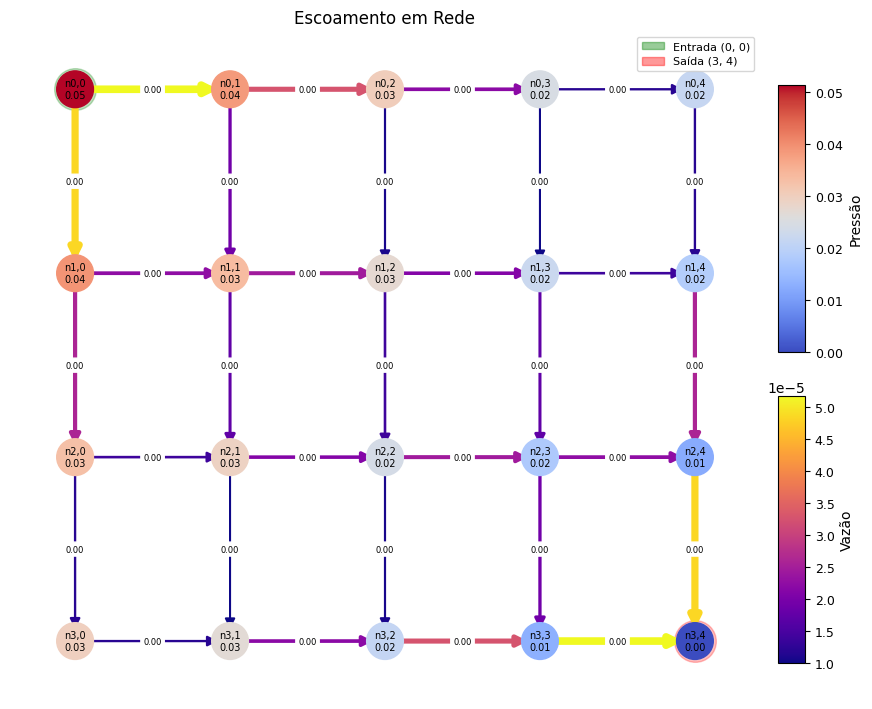

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import cm, colors as mcolors
import networkx as nx
import numpy as np

from src.ProblemaP1 import ProblemaP1
import warnings
warnings.filterwarnings("ignore")

class GridP1(ProblemaP1):

    """
    Grid n (linhas) × m (colunas) de canos com propriedades uniformes.
    Arestas direcionadas: esquerda→direita e cima→baixo.
    Entrada: nó (0, 0)         — pressão alta (Q_ext > 0)
    Saída:   nó (n-1, m-1)     — pressão baixa (Q_ext < 0)
    """

    def __init__(self, n, m, area, length, mu, patm,
                 Q_in=1.0, Q_out=None):
        """
        n, m    : dimensões do grid (linhas × colunas)
        area    : área da seção transversal dos canos
        length  : comprimento de cada cano
        mu      : viscosidade
        patm    : pressão de referência (saída)
        Q_in    : fluxo de entrada concentrado no nó (0, 0)
        Q_out   : fluxo de saída concentrado no nó (n-1, m-1)
        """
        self.n = n
        self.m = m

        nodes, edges = self._build_grid(n, m, area, length)

        Q_ext = self._build_Q_ext(n, m, Q_in, Q_out)

        super().__init__(nodes=nodes, edges=edges, mu=mu, patm=patm, Q_ext=Q_ext)

    # ── construtores internos ─────────────────────────────────────────────────

    @staticmethod
    def _node_id(i, j):
        return f"n{i},{j}"

    def _build_grid(self, n, m, area, length):
        nodes = {}
        edges = {}

        for i in range(n):
            for j in range(m):
                nid = self._node_id(i, j)
                nodes[nid] = {}
                edges[nid] = {}

        pipe = {"area": area, "length": length}

        for i in range(n):
            for j in range(m):
                u = self._node_id(i, j)
                # horizontal: esquerda → direita
                if j + 1 < m:
                    v = self._node_id(i, j + 1)
                    edges[u][v] = dict(pipe)
                # vertical: cima → baixo
                if i + 1 < n:
                    v = self._node_id(i + 1, j)
                    edges[u][v] = dict(pipe)

        return nodes, edges

    def _build_Q_ext(self, n, m, Q_in, Q_out):
        if Q_out is None:
            Q_out = -Q_in

        Q_ext = {}
        # Zera o fluxo em todos os nós inicialmente
        for i in range(n):
            for j in range(m):
                nid = self._node_id(i, j)
                Q_ext[nid] = 0.0

        # Define pontualmente a entrada e a saída
        Q_ext[self._node_id(0, 0)] = Q_in
        Q_ext[self._node_id(n - 1, m - 1)] = Q_out

        return Q_ext

    # ── posições em grid para o plot ──────────────────────────────────────────

    def _grid_positions(self):
        pos = {}
        for i in range(self.n):
            for j in range(self.m):
                nid = self._node_id(i, j)
                pos[nid] = (j, -(i))   # x=coluna, y=-linha (cima→baixo)
        return pos

    # ── plot especializado ────────────────────────────────────────────────────

    def plot_grid(self, figsize=None, precision=2,
                  node_cmap="coolwarm", edge_cmap="plasma",
                  show_node_labels=True, show_edge_labels=False):

        G = self.get_network()
        pos = self._grid_positions()

        if figsize is None:
            figsize = (max(6, self.m * 1.8), max(5, self.n * 1.8))

        fig, ax = plt.subplots(figsize=figsize)

        node_sm = None
        edge_sm = None

        # ── cores dos nós (pressão) ───────────────────────────────────────────
        node_order = list(G.nodes())
        pressures = np.array([G.nodes[nd].get("pressao", np.nan) for nd in node_order], dtype=float)

        has_p = np.isfinite(pressures).any()
        if has_p:
            vmin, vmax = pressures[np.isfinite(pressures)].min(), pressures[np.isfinite(pressures)].max()
            if np.isclose(vmin, vmax): vmax = vmin + 1
            node_norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
            nx.draw_networkx_nodes(G, pos, node_size=700,
                                   node_color=pressures,
                                   cmap=cm.get_cmap(node_cmap),
                                   vmin=vmin, vmax=vmax, ax=ax)
            
            node_sm = cm.ScalarMappable(norm=node_norm, cmap=cm.get_cmap(node_cmap))
            node_sm.set_array([])
        else:
            nx.draw_networkx_nodes(G, pos, node_size=700, node_color="skyblue", ax=ax)

        # ── cores das arestas (vazão) ───────────────────────────────────────
        edge_order = list(G.edges())
        flows = np.array([abs(G.edges[e].get("vazao", np.nan)) for e in edge_order], dtype=float)

        has_q = np.isfinite(flows).any()
        if has_q:
            fmin, fmax = flows[np.isfinite(flows)].min(), flows[np.isfinite(flows)].max()
            if np.isclose(fmin, fmax): fmax = fmin + 1
            edge_norm = mcolors.Normalize(vmin=fmin, vmax=fmax)
            widths = np.interp(flows, (fmin, fmax), (1.5, 5.5))
            nx.draw_networkx_edges(G, pos,
                                   edge_color=flows,
                                   edge_cmap=cm.get_cmap(edge_cmap),
                                   edge_vmin=fmin, edge_vmax=fmax,
                                   width=widths,
                                   arrows=True,
                                   arrowstyle="-|>", arrowsize=15,
                                   connectionstyle="arc3,rad=0.0",
                                   ax=ax)
            
            edge_sm = cm.ScalarMappable(norm=edge_norm, cmap=cm.get_cmap(edge_cmap))
            edge_sm.set_array([])
        else:
            nx.draw_networkx_edges(G, pos, width=2, edge_color="gray",
                                   arrows=True, arrowstyle="-|>", arrowsize=15, ax=ax)

        # ── labels dos nós ────────────────────────────────────────────────────
        if show_node_labels:
            labels = {}
            for nd in node_order:
                p_val = G.nodes[nd].get("pressao", None)
                label = nd
                if p_val is not None:
                    label += f"\n{p_val:.{precision}f}"
                labels[nd] = label
            nx.draw_networkx_labels(G, pos, labels=labels, font_size=7, ax=ax)

        # ── labels das arestas ────────────────────────────────────────────────
        if show_edge_labels:
            elabels = {
                (u, v): f"{G.edges[u,v].get('vazao', 0):.{precision}f}"
                for u, v in edge_order
                if "vazao" in G.edges[u, v]
            }
            nx.draw_networkx_edge_labels(G, pos, edge_labels=elabels,
                                         font_size=6, rotate=False, ax=ax)

        # ── legenda de bordas ─────────────────────────────────────────────────
        patch_in  = mpatches.Patch(color="green",  alpha=0.4, label="Entrada (0, 0)")
        patch_out = mpatches.Patch(color="red",    alpha=0.4, label=f"Saída ({self.n-1}, {self.m-1})")
        ax.legend(handles=[patch_in, patch_out], loc="upper right", fontsize=8)
    
        # ── destaca nós de entrada e saída ────────────────────────────────────
        x_in,  y_in  = pos[self._node_id(0, 0)]
        x_out, y_out = pos[self._node_id(self.n - 1, self.m - 1)]
        
        ax.scatter(x_in,  y_in,  s=900, color="green", alpha=0.25, zorder=0)
        ax.scatter(x_out, y_out, s=900, color="red",   alpha=0.25, zorder=0)

        ax.set_title(f"Escoamento em Rede", fontsize=12)
        ax.axis("off")
        
        fig.tight_layout()
        fig.subplots_adjust(right=0.85)
        bbox = ax.get_position()
        
        # -------------------------
        # Colorbar
        # -------------------------
        if has_p and node_sm is not None:
            cax_nodes = fig.add_axes([
                bbox.x1 + 0.02,               # x
                bbox.y0 + bbox.height * 0.52, # y
                0.03,                         # largura
                bbox.height * 0.40,           # altura
            ])
            cbar_nodes = fig.colorbar(node_sm, cax=cax_nodes)
            cbar_nodes.set_label("Pressão", fontsize=10)
            cbar_nodes.ax.tick_params(labelsize=9)

        if has_q and edge_sm is not None:
            cax_edges = fig.add_axes([
                bbox.x1 + 0.02,               # x
                bbox.y0 + 0.05,               # y
                0.03,                         # largura
                bbox.height * 0.40,           # altura
            ])
            cbar_edges = fig.colorbar(edge_sm, cax=cax_edges)
            cbar_edges.set_label("Vazão", fontsize=10)
            cbar_edges.ax.tick_params(labelsize=9)

        plt.show()


# ── Exemplo de uso (Requer implementação de solve()) ────────────────────────
grid = GridP1(
    n=4, m=5,
    area=0.01,
    length=1.0,
    mu=1e-3,
    patm=0.0,
    Q_in=1e-4,
)

grid.solve()
grid.plot_grid(show_edge_labels=True)

In [8]:
"""
Benchmark do ProblemaP2 em grids n×n (rede predial, escoamento laminar).
Mede o tempo total de: build + setup + solve (P1) + run Monte Carlo (P2).

Tabela de saída: n, V, E, n_samples, tempo_median_s

Metodologia anti-viés:
- warm-up em n mínimo
- amostragem intercalada em ordem aleatória
- mediana como estimador robusto
"""

import time
import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

# --- ajuste os imports para o seu projeto ---
from src.ProblemaP1 import ProblemaP1
from src.ProblemaP2 import ProblemaP2


# -------------------------------------------------------
# Parâmetros "água predial" (SI)
# -------------------------------------------------------
def predial_params():
    mu   = 1.0e-3
    D    = 0.010
    area = np.pi * D**2 / 4.0
    length = 1.0
    Q_in   = 2.0e-5
    patm   = 0.0
    return dict(mu=mu, area=area, length=length, Q_in=Q_in, patm=patm)


# -------------------------------------------------------
# Parâmetros Monte Carlo do P2
# -------------------------------------------------------
def p2_params():
    return dict(
        r_prob   = 0.10,   # probabilidade de obstrução por aresta
        alpha    = 2.0,    # fator de redução de condutância
        P_max    = 1e5,    # pressão máxima admissível (Pa)
    )


# -------------------------------------------------------
# Construção do grid como instância ProblemaP1
# -------------------------------------------------------
def make_p1_instance(n, mu, patm, area, length, Q_in):
    nodes = {(i, j): {} for i in range(n) for j in range(n)}
    edges = {}
    A, L = float(area), float(length)

    for i in range(n):
        for j in range(n):
            u = (i, j)
            out = {}
            if j + 1 < n:
                out[(i, j+1)] = {"area": A, "length": L}
            if i + 1 < n:
                out[(i+1, j)] = {"area": A, "length": L}
            if out:
                edges[u] = out

    Q_ext = {(i, j): 0.0 for i in range(n) for j in range(n)}
    Q_ext[(0, n-1)]   = +float(Q_in)   # fonte: canto superior direito
    Q_ext[(n-1, 0)]   = -float(Q_in)   # sumidouro: canto inferior esquerdo

    p1 = ProblemaP1(nodes=nodes, edges=edges, mu=float(mu),
                    patm=float(patm), Q_ext=Q_ext)
    return p1


def make_p2_instance(n, prm, p2_prm, n_samples, seed=None):
    """
    Cria ProblemaP2 a partir de uma instância P1 já resolvida.
    O P1 precisa de setup() + solve() antes de ser passado ao P2.
    """
    p1 = make_p1_instance(n, **prm)
    p1.solve()

    p2 = ProblemaP2(
        p1_instance = p1,
        n_samples   = n_samples,
        seed        = seed,
        **p2_prm,
    )
    return p2


def grid_counts(n):
    return n * n, 2 * n * (n - 1)


# -------------------------------------------------------
# Benchmark
# -------------------------------------------------------
def run_benchmark_p2(
    NS,
    N_SAMPLES_LIST,          # lista paralela a NS: n_samples por tamanho
    repeats_per_n   = 5,
    warmup          = True,
    seed            = 42,
    max_seconds_per_run = None,
):
    """
    Para cada (n, n_samples), mede o tempo total:
        build P1 + setup + solve + build P2 + p2.run()

    Parâmetros
    ----------
    NS : list[int]
        Tamanhos de grid a testar.
    N_SAMPLES_LIST : list[int]
        Número de amostras Monte Carlo para cada n em NS.
        Deve ter o mesmo comprimento que NS.
    """
    assert len(NS) == len(N_SAMPLES_LIST), "NS e N_SAMPLES_LIST devem ter o mesmo tamanho."

    rng  = np.random.default_rng(seed)
    prm  = predial_params()
    p2p  = p2_params()

    times  = {n: [] for n in NS}
    status = {n: "OK"  for n in NS}
    msg    = {n: ""    for n in NS}
    ns_map = dict(zip(NS, N_SAMPLES_LIST))

    # warm-up
    if warmup and len(NS) > 0:
        n0 = min(NS)
        try:
            p2 = make_p2_instance(n0, prm, p2p, n_samples=ns_map[n0], seed=0)
            p2.run()
        except Exception as e:
            raise RuntimeError(f"Warm-up falhou em n={n0}: {type(e).__name__}: {e}")

    remaining = set(NS)
    while remaining:
        round_ns = [n for n in remaining]
        rng.shuffle(round_ns)

        for n in round_ns:
            if status[n] != "OK":
                remaining.discard(n)
                continue
            if len(times[n]) >= repeats_per_n:
                remaining.discard(n)
                continue

            try:
                t0 = time.perf_counter()
                p2 = make_p2_instance(n, prm, p2p,
                                      n_samples=ns_map[n],
                                      seed=int(rng.integers(0, 2**31)))
                p2.run()
                t1 = time.perf_counter()

                dt = t1 - t0
                times[n].append(dt)

                if max_seconds_per_run is not None and dt > max_seconds_per_run:
                    status[n] = "SLOW"
                    msg[n] = f"dt={dt:.2f}s > limite={max_seconds_per_run}s"
                    for m in NS:
                        if m > n and status[m] == "OK":
                            status[m] = "SKIP"
                            msg[m] = f"Pulou: n={n} excedeu limite de tempo"
                    remaining.clear()
                    break

            except MemoryError:
                status[n] = "FAIL"
                msg[n] = "MemoryError"
                for m in NS:
                    if m > n and status[m] == "OK":
                        status[m] = "SKIP"
                        msg[m] = f"Pulou: n={n} estourou memória"
                remaining.clear()
                break

            except Exception as e:
                status[n] = "FAIL"
                msg[n] = f"{type(e).__name__}: {e}"
                for m in NS:
                    if m > n and status[m] == "OK":
                        status[m] = "SKIP"
                        msg[m] = f"Pulou: n={n} falhou"
                remaining.clear()
                break

    rows = []
    for n in NS:
        V, E = grid_counts(n)
        arr  = np.array(times[n], dtype=float)
        rows.append({
            "n":               n,
            "V":               V,
            "E":               E,
            "n_samples":       ns_map[n],
            "status":          status[n],
            "amostras_colet":  int(arr.size),
            "tempo_median_s":  float(np.median(arr))           if arr.size     else np.nan,
            "tempo_mean_s":    float(np.mean(arr))             if arr.size     else np.nan,
            "tempo_std_s":     float(np.std(arr, ddof=1))      if arr.size > 1 else np.nan,
            "msg":             msg[n],
        })

    return pd.DataFrame(rows) if pd is not None else rows


# -------------------------------------------------------
# Execução
# -------------------------------------------------------
if __name__ == "__main__":
    # Para o P2, o custo é  O(n_samples × custo_P1(n)).
    # Mantenha n_samples fixo (ex: 200) para comparar só o efeito de n,
    # ou aumente junto com n para ver o custo combinado.

    NS = [5, 10, 15, 20, 30, 40, 50, 75, 100]

    # Opção A — n_samples fixo (isola efeito do tamanho da rede)
    N_SAMPLES_FIXED = 200
    N_SAMPLES_LIST  = [N_SAMPLES_FIXED] * len(NS)

    # Opção B — n_samples cresce com n (descomente para usar)
    # N_SAMPLES_LIST = [max(50, 500 // n) * n for n in NS]

    print("=== Benchmark ProblemaP2 (rede predial n×n) ===")
    print(f"n_samples fixo = {N_SAMPLES_FIXED}  |  repeats_per_n = 5\n")

    df = run_benchmark_p2(
        NS,
        N_SAMPLES_LIST,
        repeats_per_n       = 5,
        warmup              = True,
        seed                = 42,
        max_seconds_per_run = None,   # ex: 60 para parar automaticamente
    )

    cols_resumo   = ["n", "V", "E", "n_samples", "status", "tempo_median_s"]
    cols_completo = ["n", "V", "E", "n_samples", "status",
                     "amostras_colet", "tempo_median_s", "tempo_mean_s", "tempo_std_s", "msg"]

    if pd is not None:
        print("--- Tabela resumo ---")
        print(df[cols_resumo].to_string(index=False))
        print("\n--- Tabela completa ---")
        print(df[cols_completo].to_string(index=False))
    else:
        for r in df:
            print(r)

=== Benchmark ProblemaP2 (rede predial n×n) ===
n_samples fixo = 200  |  repeats_per_n = 5



KeyboardInterrupt: 